# Import all Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (
    precision_score,
    accuracy_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report
)

## Load csv

In [28]:
df = pd.read_csv("clean_data.csv") 

In [29]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_log,Hour
0,-1.370413,1.095589,-0.668018,-0.024219,1.675652,3.823629,-0.634559,1.836666,-0.485368,-0.547920,...,-0.609795,0.027077,0.986022,0.079739,-0.463951,0.063528,0.006793,0,0.313613,-0.866491
1,1.805238,0.961264,-1.717212,4.094625,0.938666,-0.227785,0.152911,0.066753,-1.073784,0.334537,...,-0.450959,0.098530,-0.662272,-0.150154,-0.098852,-0.000030,0.017622,0,0.307105,-0.354251
2,-1.789123,0.941366,1.432897,-1.318458,-0.450124,-1.290731,0.933642,-0.306360,0.917978,0.722699,...,-0.202022,-0.017159,0.740137,-0.183085,0.692176,0.488185,0.418299,0,0.671760,1.353215
3,-0.711379,-1.431688,0.630874,-2.551985,0.509280,-0.565154,0.258866,-0.289951,-2.680067,1.154872,...,-1.064836,0.435373,-0.932473,-0.459677,-0.759301,-0.094306,-0.053401,0,1.110565,-0.354251
4,1.303287,1.023966,-3.187599,0.468391,3.353988,2.431416,0.184510,0.622721,-0.556254,-1.485591,...,-0.823366,-0.241908,0.674554,1.012236,-0.278656,0.041260,0.089912,0,-1.490648,-0.524998


# Feature selection & Target

In [30]:
X=df.drop("Class",axis=1)
y=df["Class"]

## Train Test Split

In [31]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [32]:
print(y_train.value_counts())
print("")
print(y_test.value_counts())

Class
0    39931
1       69
Name: count, dtype: int64

Class
0    9983
1      17
Name: count, dtype: int64


## Original Data

In [33]:
X_original=X_train.copy()

y_original=y_train.copy()

## Apply Smote 

In [34]:
smote=SMOTE(
    random_state=42,
    sampling_strategy=0.1
)

X_smote,y_smote=smote.fit_resample(X_train,y_train)

## Apply UnderSampling

In [35]:
under=RandomUnderSampler(
    random_state=42,
    sampling_strategy=0.1
)

X_under,y_under=under.fit_resample(X_train,y_train)

In [36]:
print(y_original.value_counts())

print(y_smote.value_counts())

print(y_under.value_counts())

Class
0    39931
1       69
Name: count, dtype: int64
Class
0    39931
1     3993
Name: count, dtype: int64
Class
0    690
1     69
Name: count, dtype: int64


## Logistic on Original Data

In [38]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [39]:
y_pred = lr.predict(X_test)

In [40]:
y_prob = lr.predict_proba(X_test)[:,1]

## Evalutution MatriX

In [41]:
print("Logistic Regression Results")
print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))
print("PR-AUC    :", average_precision_score(y_test, y_prob))

Logistic Regression Results
Accuracy : 0.9756
Precision : 0.06513409961685823
Recall    : 1.0
F1 Score  : 0.1223021582733813
PR-AUC    : 0.7811395995154227


## Logistic on Smote

In [42]:
lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_smote.fit(X_smote, y_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [43]:
y_pred = lr_smote.predict(X_test)

In [44]:
y_prob = lr_smote.predict_proba(X_test)[:,1]

## Evalutation Matrix (Smote)

In [45]:
print("Logistic Regression (SMOTE)")
print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))
print("PR-AUC    :", average_precision_score(y_test, y_prob))

Logistic Regression (SMOTE)
Accuracy : 0.9962
Precision : 0.3090909090909091
Recall    : 1.0
F1 Score  : 0.4722222222222222
PR-AUC    : 0.813276782412327


## Logistic on UnderSampling Data

In [46]:
lr_under = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_under.fit(X_under, y_under)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [47]:
y_pred = lr_under.predict(X_test)

In [48]:
y_prob = lr_under.predict_proba(X_test)[:,1]

## Evalutation Matrix (under)

In [49]:
print("Logistic Regression (Under Sampling)")
print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))
print("PR-AUC    :", average_precision_score(y_test, y_prob))

Logistic Regression (Under Sampling)
Accuracy : 0.9945
Precision : 0.22857142857142856
Recall    : 0.9411764705882353
F1 Score  : 0.367816091954023
PR-AUC    : 0.8128361353129155


## Hyperparameter Tuning for Logistic Regression

In [55]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],
    "class_weight": [None, "balanced"]

}

grid =  RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring="average_precision",
    random_state=42,
    n_jobs=-1
)

grid.fit(X_smote, y_smote)

c:\Users\Shyamdev verma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Shyamdev verma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... v

In [56]:
print("Best Parameters :", grid.best_params_)
print("Best CV Score :", grid.best_score_)

Best Parameters : {'solver': 'saga', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 100}
Best CV Score : 0.9753189893189459


## Best Logistic Regression Model

In [57]:
best_lr = grid.best_estimator_

y_pred = best_lr.predict(X_test)

y_prob = best_lr.predict_proba(X_test)[:,1]


## Evaluation & Classification Report 

In [58]:

print("\nClassification Report\n")

print(classification_report(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("Precision :", precision_score(y_test,y_pred))
print("Recall :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("PR-AUC :", average_precision_score(y_test,y_prob))


Classification Report

              precision    recall  f1-score   support

           0       1.00      0.97      0.99      9983
           1       0.06      0.94      0.11        17

    accuracy                           0.97     10000
   macro avg       0.53      0.96      0.55     10000
weighted avg       1.00      0.97      0.99     10000

accuracy: 0.9737
Precision : 0.05755395683453238
Recall : 0.9411764705882353
F1 Score : 0.10847457627118644
PR-AUC : 0.7504945807189597


## ROC Curve

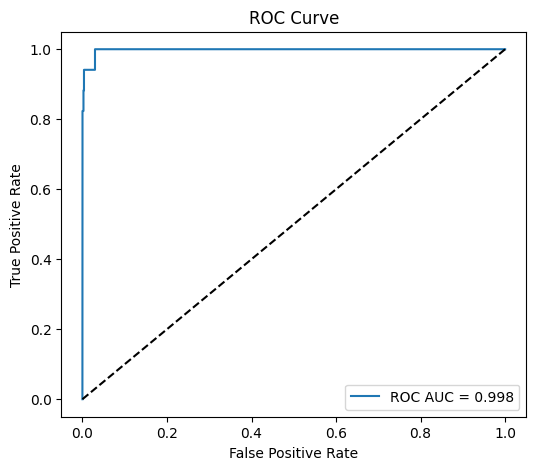

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC AUC = %.3f" % roc_auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Precision-Recall Curve

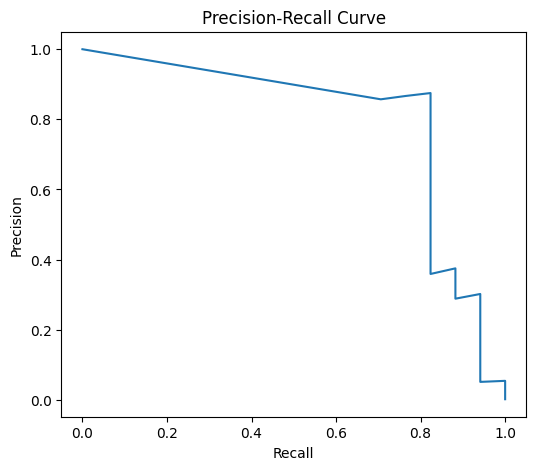

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## Best Threshold (Maximum F1)

In [ ]:
import numpy as np

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("Best Threshold =", best_threshold)
print("Best F1 Score =", f1_scores[best_index])

Best Threshold = 0.9999999999260818
Best F1 Score = 0.8484848484348944


## Threshold with Recall ≥ 0.90

In [ ]:
valid = np.where(recall[:-1] >= 0.90)[0]

best_recall_index = valid[np.argmax(precision[:-1][valid])]

threshold_90 = thresholds[best_recall_index]

print("Threshold =", threshold_90)
print("Precision =", precision[best_recall_index])
print("Recall =", recall[best_recall_index])

Threshold = 0.9859436028032258
Precision = 0.3018867924528302
Recall = 0.9411764705882353


## Evaluate at Best F1 Threshold

In [74]:
pred_best = (y_prob >= best_threshold).astype(int)
print("accuracy :",accuracy_score(y_test,pred_best))
print("Precision :", precision_score(y_test, pred_best))
print("Recall :", recall_score(y_test, pred_best))
print("F1 Score :", f1_score(y_test, pred_best))
print("PR-AUC :", average_precision_score(y_test, y_prob))

accuracy : 0.9995
Precision : 0.875
Recall : 0.8235294117647058
F1 Score : 0.8484848484848485
PR-AUC : 0.7504945807189597


## Evaluate at Recall ≥ 0.90 Threshold

In [75]:
pred_90 = (y_prob >= threshold_90).astype(int)
print("accuracy :",accuracy_score(y_test,pred_90))
print("Precision :", precision_score(y_test, pred_90))
print("Recall :", recall_score(y_test, pred_90))
print("F1 Score :", f1_score(y_test, pred_90))
print("PR-AUC :", average_precision_score(y_test, y_prob))

accuracy : 0.9962
Precision : 0.3018867924528302
Recall : 0.9411764705882353
F1 Score : 0.45714285714285713
PR-AUC : 0.7504945807189597


# Conclusion


This project successfully developed a Logistic Regression model for detecting fraudulent credit card transactions. The dataset was preprocessed using feature engineering, feature scaling, and imbalance handling techniques such as SMOTE and Random Under Sampling. The performance of Logistic Regression was evaluated on the original, SMOTE, and undersampled datasets using Precision, Recall, F1-Score, and PR-AUC.

Threshold optimization was then performed using the Precision-Recall Curve. Instead of using the default threshold of 0.5, an optimal threshold was selected that maximized the F1-Score. Another threshold was chosen to achieve Recall ≥ 0.90, allowing the model to detect more fraudulent transactions while maintaining reasonable precision. This demonstrated that selecting an appropriate decision threshold can significantly improve fraud detection performance

# Performance Comparison (Before vs After Tuning)

| Metric    | Before Tuning   | After  Tuning  |
| --------- | --------------- | ---------------------------- |
| Accuracy  |   0.97    |    0.99        |
| Precision |   0.23    |    0.05        |
| Recall    |   0.94    |    0.94        |
| F1-Score  |   0.37    |    0.45        |
| PR-AUC    |   0.81    |    0.75        |


Overall, the Logistic Regression model proved to be a simple, fast, and effective baseline for fraud detection. It demonstrated that appropriate preprocessing, handling of class imbalance, hyperparameter tuning, and threshold optimization can significantly improve the detection of fraudulent transactions while reducing missed fraud cases. This approach provides a practical solution for real-world credit card fraud detection systems.